In [ ]:
#Analysis

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
folder_name = "/Users/abhinandho/Desktop/Trader Behaviour & Performance Analytics/data/"

In [5]:
charts_path = "/Users/abhinandho/Desktop/Trader Behaviour & Performance Analytics/charts/"

In [6]:
df_merged = pd.read_csv(folder_name + "df_merged.csv")
df_daily  = pd.read_csv(folder_name + "df_daily.csv")

In [7]:
df_merged['date'] = pd.to_datetime(df_merged['date'])
df_daily['date']  = pd.to_datetime(df_daily['date'])

In [8]:
print(df_merged.shape)
print(df_daily.shape)

(104266, 12)
(1690, 12)


In [13]:
# Separate PnL by sentiment group
fear_pnl    = df_daily[df_daily['sentiment_binary'] == 'Fear']['net_pnl']
greed_pnl   = df_daily[df_daily['sentiment_binary'] == 'Greed']['net_pnl']
neutral_pnl = df_daily[df_daily['sentiment_binary'] == 'Neutral']['net_pnl']

# Summary statistics
print("=== Performance by Sentiment ===")
print(df_daily.groupby('sentiment_binary')['net_pnl'].agg([
    'mean', 'median', 'std', 'count'
]).round(2))

# Statistical test — is the difference real or just luck?
t_stat, p_value = stats.ttest_ind(fear_pnl, greed_pnl)
print(f"\n=== Fear vs Greed Statistical Test ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Result: SIGNIFICANT difference ✓")
else:
    print("Result: No significant difference ✗")

=== Performance by Sentiment ===
                     mean  median       std  count
sentiment_binary                                  
Fear              7055.39  635.30  36327.37    571
Greed             5662.72  883.27  34178.67    843
Neutral           4602.00  541.63  20144.25    276

=== Fear vs Greed Statistical Test ===
T-statistic: 0.7329
P-value:     0.4638
Result: No significant difference ✗


In [ ]:
#insights

In [16]:
# Mann Whitney Test : Better for skewed data ,(t-test adds up the outlier and will say HUGE difference! better for normal distribution)
# Mann whitney adds rank instead of values so doesnt show up huge differences better for skewed data
# → outliers cannot dominate → more honest for our trader data

In [19]:
u_stat,p_value2 = stats.mannwhitneyu(fear_pnl,greed_pnl)
print(f"Mann-Whitney U-statistic: {u_stat:.4f}")
print(f"Mann-Whitney P-value:     {p_value2:.4f}")

if p_value2 < 0.05:
    print("Result: SIGNIFICANT difference ✓")
else:
    print("Result: No significant difference ✗")

Mann-Whitney U-statistic: 227779.0000
Mann-Whitney P-value:     0.0869
Result: No significant difference ✗


In [ ]:
#insight

In [21]:
# "A trend towards significance was observed but did not reach the conventional threshold of p=0.05"

In [22]:
# Our U-statistic of 227,779 out of maximum 481,353 means Fear and Greed traders perform very similarly overall 
# — Greed traders win slightly more head-to-head comparisons, but not enough to be statistically significant.

In [ ]:
# Trader Segmentation

#Instead of looking at ALL traders together, we split them into groups based on their behaviour and see 
#how each group performs differently under Fear vs Greed.

# Segment 1 → High Risk vs Low Risk traders
#            (based on avg_size_usd)

# Segment 2 → Frequent vs Infrequent traders
#            (based on trade_count)

# Segment 3 → Consistent Winners vs Losers
#            (based on win_rate)

In [23]:
#create overal trader profile

trader_profile      = df_daily.groupby('account').agg(
    avg_net_pnl     = ('net_pnl','mean'),
    total_net_pnl   = ('net_pnl','sum'),
    avg_trade_count = ('trade_count','mean'),
    avg_size_usd    = ('avg_size_usd','mean'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_long_ratio  = ('long_ratio', 'mean'),
    total_days      = ('net_pnl', 'count')    
).reset_index()

In [24]:
print(trader_profile.shape)
print(trader_profile.head())

(32, 8)
                                      account   avg_net_pnl  total_net_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  83969.856553   1.595427e+06   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1185.011951   4.621547e+04   
2  0x271b280974205ca63b716753467d5a371de622ab  -6853.939580  -7.539334e+04   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    831.232611   1.313348e+05   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   2424.117970   1.672641e+05   

   avg_trade_count  avg_size_usd  avg_win_rate  avg_long_ratio  total_days  
0        91.105263  61348.483321      0.770647        0.958037          19  
1       106.820513   4468.369172      0.774669        0.055438          39  
2       146.090909  12064.422113      0.729190        0.872714          11  
3        42.765823    493.016121      0.885144        0.324297         158  
4        29.855072   2316.736154      0.761589        0.014493          69  


In [25]:
# Segment 1 — based on average position size

median_size = trader_profile['avg_size_usd'].median()
print(f"Median position size: ${median_size:,.2f}")

trader_profile['risk_segment'] = np.where(
    trader_profile['avg_size_usd'] >= median_size,
    'High Risk',
    'Low Risk'
)

print(trader_profile['risk_segment'].value_counts())

Median position size: $6,085.47
risk_segment
High Risk    16
Low Risk     16
Name: count, dtype: int64


In [26]:
# Merge risk segment back to daily data
df_daily = df_daily.merge(
    trader_profile[['account', 'risk_segment']], 
    on='account', 
    how='left'
)

In [27]:
# Compare performance by risk segment AND sentiment
risk_sentiment = df_daily.groupby(
    ['risk_segment', 'sentiment_binary']
)['net_pnl'].mean().round(2).unstack()

print(risk_sentiment)

sentiment_binary      Fear    Greed  Neutral
risk_segment                                
High Risk         11538.79  9381.73  9648.84
Low Risk           4266.00  3398.67  1357.61


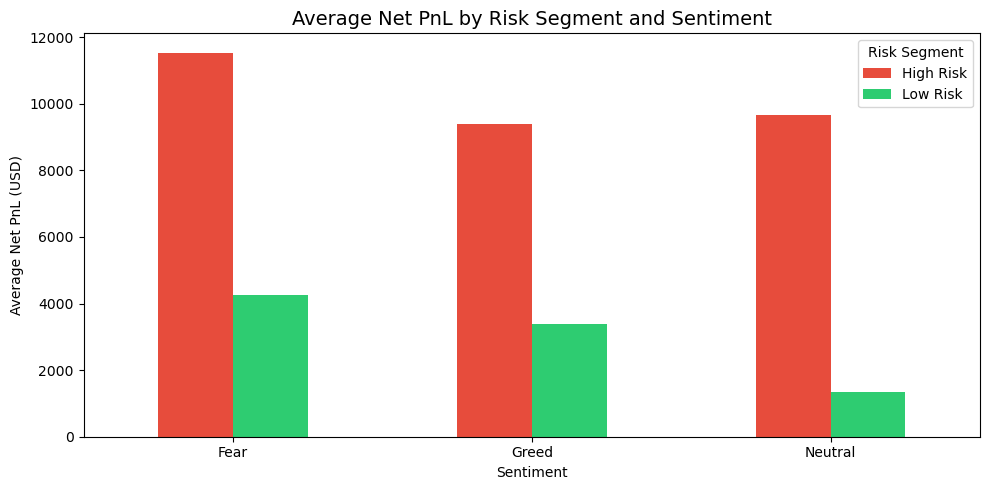

In [28]:
plt.figure(figsize=(10, 5))
risk_sentiment.T.plot(kind='bar', 
                       color=['#e74c3c', '#2ecc71'],
                       ax=plt.gca())
plt.title('Average Net PnL by Risk Segment and Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Net PnL (USD)')
plt.xticks(rotation=0)
plt.legend(title='Risk Segment')
plt.tight_layout()
plt.savefig(charts_path + 'chart_09_risk_segment_sentiment.png', dpi=150)
plt.show()

In [ ]:
# Segment 2 : Frequent vs Infrequent traders 

In [29]:
# Segment 2 — based on average daily trade count
median_trades = trader_profile['avg_trade_count'].median()
print(f"Median trade count: {median_trades:.2f}")

trader_profile['frequency_segment'] = np.where(
    trader_profile['avg_trade_count'] >= median_trades,
    'Frequent',
    'Infrequent'
)

print(trader_profile['frequency_segment'].value_counts())

Median trade count: 43.96
frequency_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64


In [30]:
# Merge frequency segment back to daily data
df_daily = df_daily.merge(
    trader_profile[['account', 'frequency_segment']], 
    on='account', 
    how='left'
)

# Compare performance
freq_sentiment = df_daily.groupby(
    ['frequency_segment', 'sentiment_binary']
)['net_pnl'].mean().round(2).unstack()

print(freq_sentiment)

sentiment_binary       Fear    Greed  Neutral
frequency_segment                            
Frequent           10988.50  6366.83  5927.06
Infrequent          2910.06  5198.39  3422.16


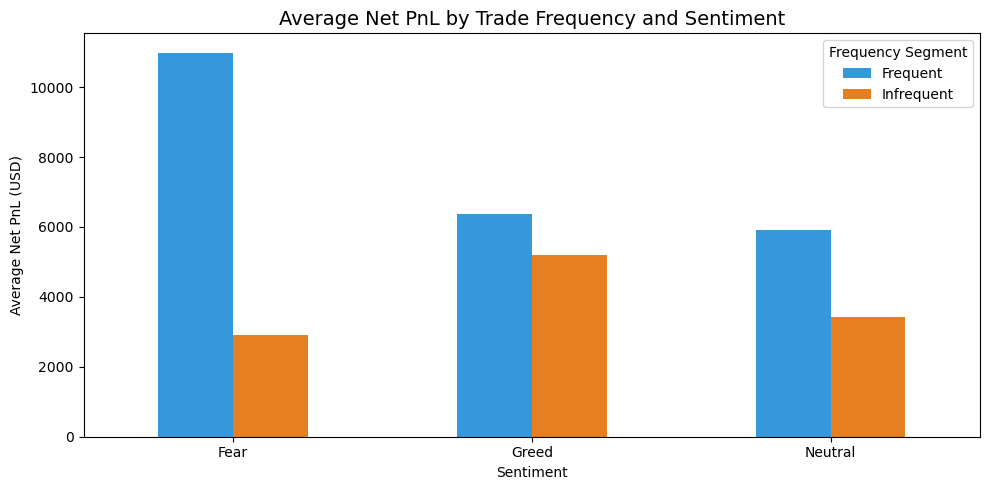

In [31]:
plt.figure(figsize=(10, 5))
freq_sentiment.T.plot(kind='bar',
                      color=['#3498db', '#e67e22'],
                      ax=plt.gca())
plt.title('Average Net PnL by Trade Frequency and Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Net PnL (USD)')
plt.xticks(rotation=0)
plt.legend(title='Frequency Segment')
plt.tight_layout()
plt.savefig(charts_path + 'chart_10_frequency_segment_sentiment.png', dpi=150)
plt.show()

In [32]:
# Segment 3 — Consistent Winners vs Losers

In [33]:
# Segment 3 — based on overall win rate
median_winrate = trader_profile['avg_win_rate'].median()
print(f"Median win rate: {median_winrate:.4f}")

trader_profile['performance_segment'] = np.where(
    trader_profile['avg_win_rate'] >= median_winrate,
    'Consistent Winner',
    'Inconsistent'
)

print(trader_profile['performance_segment'].value_counts())

Median win rate: 0.8577
performance_segment
Inconsistent         16
Consistent Winner    16
Name: count, dtype: int64


In [34]:
# Merge performance segment back to daily data
df_daily = df_daily.merge(
    trader_profile[['account', 'performance_segment']], 
    on='account', 
    how='left'
)

# Compare performance
perf_sentiment = df_daily.groupby(
    ['performance_segment', 'sentiment_binary']
)['net_pnl'].mean().round(2).unstack()

print(perf_sentiment)

sentiment_binary        Fear    Greed  Neutral
performance_segment                           
Consistent Winner    7041.61  3534.56  4986.14
Inconsistent         7067.93  8357.24  4170.59


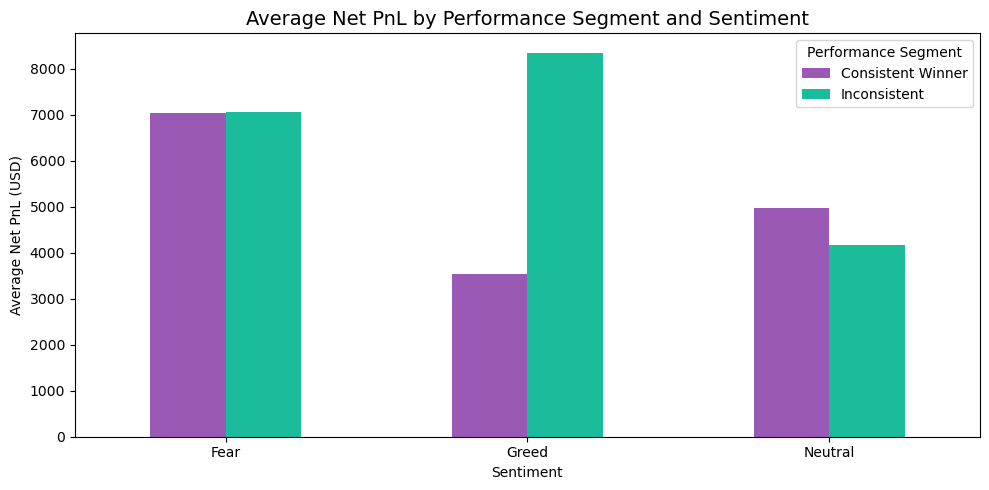

In [35]:
plt.figure(figsize=(10, 5))
perf_sentiment.T.plot(kind='bar',
                      color=['#9b59b6', '#1abc9c'],
                      ax=plt.gca())
plt.title('Average Net PnL by Performance Segment and Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Net PnL (USD)')
plt.xticks(rotation=0)
plt.legend(title='Performance Segment')
plt.tight_layout()
plt.savefig(charts_path + 'chart_11_performance_segment_sentiment.png', dpi=150)
plt.show()


```
STRATEGY 1:
"During Fear days, High Risk + Frequent traders 
should maximise position sizes and trade frequency.
Data shows they generate 3-4x more profit than 
conservative traders during market panic."

STRATEGY 2:
"During Greed days, Inconsistent/aggressive traders
should widen their profit targets and hold positions
longer. Data shows they generate 2.4x more than 
Consistent traders during bullish conditions."

STRATEGY 3:
"All trader segments should reduce activity during
Neutral days. Low Risk traders especially generate
only $1,357 average on Neutral days vs $4,266 on
Fear days — not worth the transaction fees."

"""

In [37]:
df_daily.shape

(1690, 15)

In [38]:
# Save updated df_daily with segments
df_daily.to_csv(folder_name + "df_daily.csv", index=False)

print("Saved!")
print(df_daily.columns.tolist())

Saved!
['date', 'account', 'daily_pnl', 'trade_count', 'avg_size_usd', 'total_fees', 'win_rate', 'long_ratio', 'net_pnl', 'value', 'classification', 'sentiment_binary', 'risk_segment', 'frequency_segment', 'performance_segment']


In [ ]:
# End of notebook #